In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "Age": np.random.randint(18, 60, 100),
    "Income": np.random.randint(20000, 100000, 100),
    "Score": np.random.randint(1, 100, 100)
}

df = pd.DataFrame(data)

print(df.head(10))
print("Shape:", df.shape)

   Age  Income  Score
0   56   28392     19
1   46   50535     20
2   32   98603     96
3   25   72256     71
4   38   55222     52
5   56   97373     33
6   36   99575     40
7   40   83335     39
8   28   30965     82
9   28   44538      1
Shape: (100, 3)


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print(scaled_data[:5])

[[ 1.48788435 -1.49121945 -0.95461759]
 [ 0.66539438 -0.50634208 -0.9201673 ]
 [-0.48609157  1.63162863  1.69805489]
 [-1.06183455  0.45976556  0.83679759]
 [ 0.00740241 -0.29787348  0.18224204]]


In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

print(df.head())

   Age  Income  Score  Cluster
0   56   28392     19        1
1   46   50535     20        0
2   32   98603     96        2
3   25   72256     71        2
4   38   55222     52        1


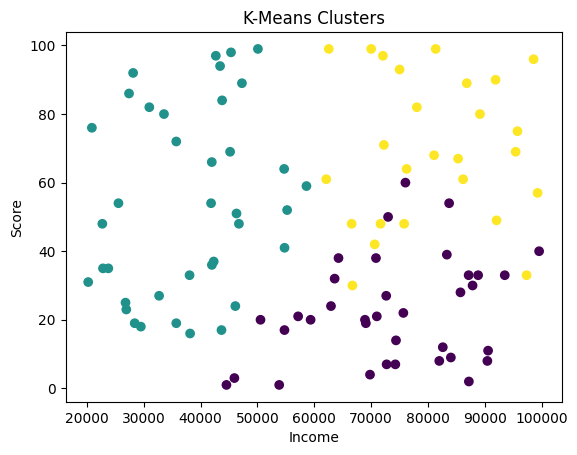

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["Income"], df["Score"], c=df["Cluster"])
plt.xlabel("Income")
plt.ylabel("Score")
plt.title("K-Means Clusters")
plt.show()

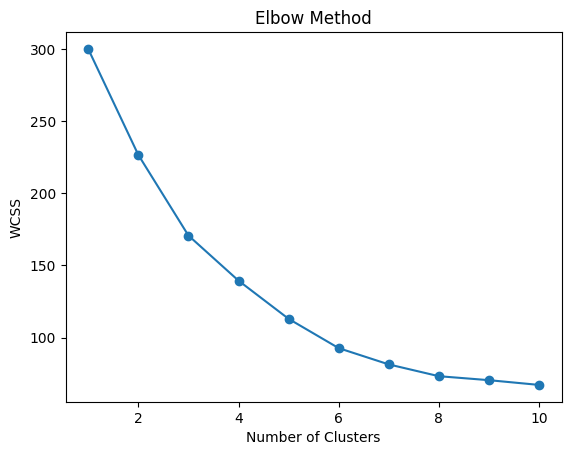

In [5]:
wcss = []

for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

print(df.head())

   Age  Income  Score  Cluster
0   56   28392     19        1
1   46   50535     20        0
2   32   98603     96        2
3   25   72256     71        2
4   38   55222     52        1
